In [344]:
import pandas as pd

In [345]:
df = pd.read_csv('dataset.csv')

# Проверка на дубликаты

In [346]:
df.duplicated().sum()

np.int64(0)

# Работа с пропусками

In [347]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17055 entries, 0 to 17054
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       17055 non-null  int64  
 1   url              17055 non-null  object 
 2   title            16998 non-null  object 
 3   year             16907 non-null  float64
 4   city             17055 non-null  object 
 5   make             17055 non-null  object 
 6   model            17055 non-null  object 
 7   price            16907 non-null  float64
 8   price_badge_raw  13628 non-null  object 
 9   price_badge      13628 non-null  object 
 10  published_date   16907 non-null  object 
 11  published_raw    16907 non-null  object 
 12  engine           16879 non-null  object 
 13  transmission     16886 non-null  object 
 14  mileage          14020 non-null  float64
 15  drive            16861 non-null  object 
 16  body             6790 non-null   object 
 17  color       

In [348]:
df = df.drop('Unnamed: 0', axis = 1)
df = df.drop('title', axis = 1)
df = df.drop('description', axis = 1)
df = df.drop('body', axis = 1)
df = df.drop('seller_type_raw', axis = 1)

In [349]:
df = df.dropna(subset = 'year')
df = df.dropna(subset = 'price')
df = df.dropna(subset = 'color')
df = df.dropna(subset = 'wheel')
df = df.dropna(subset = 'drive')
df = df.dropna(subset = 'transmission')
df = df.dropna(subset = 'engine')
df = df.dropna(subset = 'price_badge')

In [350]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13113 entries, 0 to 17054
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              13113 non-null  object 
 1   year             13113 non-null  float64
 2   city             13113 non-null  object 
 3   make             13113 non-null  object 
 4   model            13113 non-null  object 
 5   price            13113 non-null  float64
 6   price_badge_raw  13113 non-null  object 
 7   price_badge      13113 non-null  object 
 8   published_date   13113 non-null  object 
 9   published_raw    13113 non-null  object 
 10  engine           13113 non-null  object 
 11  transmission     13113 non-null  object 
 12  mileage          13052 non-null  float64
 13  drive            13113 non-null  object 
 14  color            13113 non-null  object 
 15  wheel            13113 non-null  object 
 16  hp               13109 non-null  float64
 17  seller_type      

In [351]:
df.head(1)

,url,year,city,make,model,price,price_badge_raw,price_badge,published_date,published_raw,engine,transmission,mileage,drive,color,wheel,hp,seller_type,owner_status,is_owner
0,https://auto.drom.ru/kemerovo/kia/sportage/687...,2019.0,kemerovo,kia,sportage,2099000.0,хорошая цена,хорошая,22.05.2026,Объявление 687313134 от 22.05.2026 33,"бензин, 2.0 л",АКПП,66000.0,передний,белый,левый,150.0,частник,собственник,True


так как price_badge_raw и price_badge показывают одно и то же, а именно рейтинг цены, то оставим только один признак

Аналогично с published_date и published_raw, которые также показывают одно и то же, а именно дату публикации объявления

In [352]:
df = df.drop('price_badge_raw', axis = 1)
df = df.drop('published_raw', axis = 1)

In [353]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13113 entries, 0 to 17054
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             13113 non-null  object 
 1   year            13113 non-null  float64
 2   city            13113 non-null  object 
 3   make            13113 non-null  object 
 4   model           13113 non-null  object 
 5   price           13113 non-null  float64
 6   price_badge     13113 non-null  object 
 7   published_date  13113 non-null  object 
 8   engine          13113 non-null  object 
 9   transmission    13113 non-null  object 
 10  mileage         13052 non-null  float64
 11  drive           13113 non-null  object 
 12  color           13113 non-null  object 
 13  wheel           13113 non-null  object 
 14  hp              13109 non-null  float64
 15  seller_type     13113 non-null  object 
 16  owner_status    2760 non-null   object 
 17  is_owner        2760 non-null   obje

В owner_status NaN это не пропуск, а сигнал о том, что человек не собственник, так как просто плашки собственника у него на страничке нет и поэтому ему прописывается NaN. Так что все пропуски в owner_status и is_owner (что показывает одно и то же, только первое буквами, а второе закодированно) заменим на "не собственник" и False

In [354]:
df['owner_status'] = df['owner_status'].fillna('не собственник')
df['is_owner'] = df['is_owner'].fillna(False)

/tmp/ipykernel_2844/4304185.py:2: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [355]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13113 entries, 0 to 17054
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             13113 non-null  object 
 1   year            13113 non-null  float64
 2   city            13113 non-null  object 
 3   make            13113 non-null  object 
 4   model           13113 non-null  object 
 5   price           13113 non-null  float64
 6   price_badge     13113 non-null  object 
 7   published_date  13113 non-null  object 
 8   engine          13113 non-null  object 
 9   transmission    13113 non-null  object 
 10  mileage         13052 non-null  float64
 11  drive           13113 non-null  object 
 12  color           13113 non-null  object 
 13  wheel           13113 non-null  object 
 14  hp              13109 non-null  float64
 15  seller_type     13113 non-null  object 
 16  owner_status    13113 non-null  object 
 17  is_owner        13113 non-null  bool

Заполним пробег(mileage)медианным значением по марке+модели+году

In [356]:
mileage_table = df.groupby(['make', 'model', 'year'])['mileage'].median()

In [357]:
mileage_table.head(3)

make  model  year  
audi  100    1984.0    252500.0
             1988.0    399999.5
             1989.0    377500.0
Name: mileage, dtype: float64

In [358]:
df = df.merge(mileage_table, on = ['make', 'model', 'year'], how = 'left')

In [359]:
df.head(1)

,url,year,city,make,model,price,price_badge,published_date,engine,transmission,mileage_x,drive,color,wheel,hp,seller_type,owner_status,is_owner,mileage_y
0,https://auto.drom.ru/kemerovo/kia/sportage/687...,2019.0,kemerovo,kia,sportage,2099000.0,хорошая,22.05.2026,"бензин, 2.0 л",АКПП,66000.0,передний,белый,левый,150.0,частник,собственник,True,121000.0


In [360]:
df['mileage_x'] = df['mileage_x'].fillna(df['mileage_y'])

In [361]:
df = df.drop('mileage_y', axis = 1)

In [362]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13113 entries, 0 to 13112
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             13113 non-null  object 
 1   year            13113 non-null  float64
 2   city            13113 non-null  object 
 3   make            13113 non-null  object 
 4   model           13113 non-null  object 
 5   price           13113 non-null  float64
 6   price_badge     13113 non-null  object 
 7   published_date  13113 non-null  object 
 8   engine          13113 non-null  object 
 9   transmission    13113 non-null  object 
 10  mileage_x       13105 non-null  float64
 11  drive           13113 non-null  object 
 12  color           13113 non-null  object 
 13  wheel           13113 non-null  object 
 14  hp              13109 non-null  float64
 15  seller_type     13113 non-null  object 
 16  owner_status    13113 non-null  object 
 17  is_owner        13113 non-null 

Не так много всего получилось заполнить, остальные строки удаляем

In [363]:
df = df.dropna(subset = 'mileage_x')

In [364]:
df = df.rename(columns = {'mileage_x': 'mileage'})

In [365]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13105 entries, 0 to 13112
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             13105 non-null  object 
 1   year            13105 non-null  float64
 2   city            13105 non-null  object 
 3   make            13105 non-null  object 
 4   model           13105 non-null  object 
 5   price           13105 non-null  float64
 6   price_badge     13105 non-null  object 
 7   published_date  13105 non-null  object 
 8   engine          13105 non-null  object 
 9   transmission    13105 non-null  object 
 10  mileage         13105 non-null  float64
 11  drive           13105 non-null  object 
 12  color           13105 non-null  object 
 13  wheel           13105 non-null  object 
 14  hp              13101 non-null  float64
 15  seller_type     13105 non-null  object 
 16  owner_status    13105 non-null  object 
 17  is_owner        13105 non-null  bool

In [366]:
hp_table = df.groupby(['make', 'model', 'year'])['hp'].median()

In [367]:
hp_table.head(1)

,,,hp
make,model,year,
audi,100,1984.0,75.0


In [368]:
df = df.merge(hp_table, on = ['make', 'model', 'year'], how = 'left')
df['hp_x'] = df['hp_x'].fillna(df['hp_y'])
df = df.drop('hp_y', axis = 1)

In [369]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13105 entries, 0 to 13104
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             13105 non-null  object 
 1   year            13105 non-null  float64
 2   city            13105 non-null  object 
 3   make            13105 non-null  object 
 4   model           13105 non-null  object 
 5   price           13105 non-null  float64
 6   price_badge     13105 non-null  object 
 7   published_date  13105 non-null  object 
 8   engine          13105 non-null  object 
 9   transmission    13105 non-null  object 
 10  mileage         13105 non-null  float64
 11  drive           13105 non-null  object 
 12  color           13105 non-null  object 
 13  wheel           13105 non-null  object 
 14  hp_x            13102 non-null  float64
 15  seller_type     13105 non-null  object 
 16  owner_status    13105 non-null  object 
 17  is_owner        13105 non-null 

In [370]:
df = df.dropna(subset = 'hp_x')
df = df.rename(columns = {'hp_x': 'hp'})

In [371]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13102 entries, 0 to 13104
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             13102 non-null  object 
 1   year            13102 non-null  float64
 2   city            13102 non-null  object 
 3   make            13102 non-null  object 
 4   model           13102 non-null  object 
 5   price           13102 non-null  float64
 6   price_badge     13102 non-null  object 
 7   published_date  13102 non-null  object 
 8   engine          13102 non-null  object 
 9   transmission    13102 non-null  object 
 10  mileage         13102 non-null  float64
 11  drive           13102 non-null  object 
 12  color           13102 non-null  object 
 13  wheel           13102 non-null  object 
 14  hp              13102 non-null  float64
 15  seller_type     13102 non-null  object 
 16  owner_status    13102 non-null  object 
 17  is_owner        13102 non-null  bool

Пропуски очищены!

#  Univariant Analysis

Теперь давайте посмотрим как у нас выглядит каждый признак


**0.url** - ссылка на объявление, в нашем случае уникальный идентификатор автомобиля. Именно по ссылке производился весь сбор данных в скрапинге

**1.year** - год выпуска конкретного автомобиля

**2.city** - город, в котором осуществляется продажа конкретного авто

**3.make** - производитель (марка) автомобиля

**4.model** - модель автомобиля

**5.price** - цена конкретного автомобиля

**6.price_badge** - знак оценки цены (хорошая, нормальная и тд)

**7.published_date** - дата публикации объявления

**8.engine** - тип топлива, объем двигателя и дополнительное оборудование

**9.transmission** - тип коробки передач у конкретного автомобиля

**10.mileage** - пробег конкретного автомобиля

**11.drive** - тип привода конкретного автомобиля

**12.color** - цвет конкретного автомобиля

**13.wheel** - расположение руля в конкретном автомобиле

**14.hp** - количество лошадиных сил конкретного автомобиля

**15.seller_type** - тип продавца

**16.owner_status** - статус продавца (собственник или нет)

**17.is_owner** - флаг статуса продавца (собственник или нет)


# Корреляция признаков

In [372]:
import plotly.express as px

df_numeric = df[['year', 'price', 'mileage', 'hp']]

corr_matrix = df_numeric.corr(method = 'spearman')
fig = px.imshow(corr_matrix, text_auto='.2f', color_continuous_scale='RdBu', title = 'Корреляция признаков между собой')
fig.update_xaxes(tickfont_size=10)
fig.update_yaxes(tickfont_size=10)
fig.show()

Год и пробег имеют сильную отрицательную зависимость. Чем больше год, тем меньше пробег

Цена и год имеют сильную положительную зависимость - чем больше год, тем больше цена

Пробег и цена имеют отприцательную зависимость - чем больше пробег, тем меньше цена

Количество лошадиных сил и цена имеют сильную положительную зависимость - чем больше лошадиных сил, тем больше цена

In [373]:
import matplotlib.pyplot as plt

# 1.year

In [374]:
df = df[df['year'] <= 2026]
df = df[df['year'] >= 1980]

Text(0, 0.5, 'Количество автомобилей')

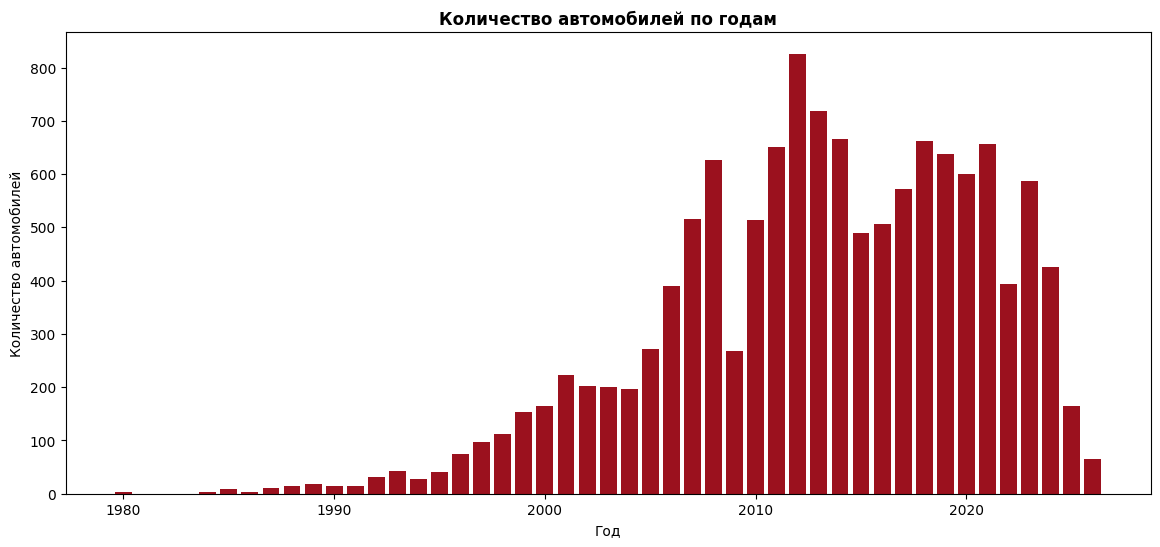

In [375]:
years_pivot = pd.pivot_table(df, values = 'url', index = 'year', aggfunc = 'count')
plt.figure(figsize = (14, 6))
plt.bar(years_pivot.index, years_pivot['url'], color = '#9B111E')


plt.title('Количество автомобилей по годам', fontweight = 'bold')
plt.xlabel('Год')
plt.ylabel('Количество автомобилей')


Боллше всего в объявлениях машин производства с 2006 по 2024 год. Пик достигается у машин 2012 года

# 2.city

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'chita'),
  Text(1, 0, 'kazan'),
  Text(2, 0, 'novokuznetsk'),
  Text(3, 0, 'rostov-na-donu'),
  Text(4, 0, 'tomsk'),
  Text(5, 0, 'surgut'),
  Text(6, 0, 'chelyabinsk'),
  Text(7, 0, 'habarovsk'),
  Text(8, 0, 'vladivostok'),
  Text(9, 0, 'ekaterinburg'),
  Text(10, 0, 'tyumen'),
  Text(11, 0, 'krasnodar'),
  Text(12, 0, 'barnaul'),
  Text(13, 0, 'kemerovo'),
  Text(14, 0, 'irkutsk'),
  Text(15, 0, 'spb'),
  Text(16, 0, 'omsk'),
  Text(17, 0, 'krasnoyarsk'),
  Text(18, 0, 'novosibirsk'),
  Text(19, 0, 'moscow')])

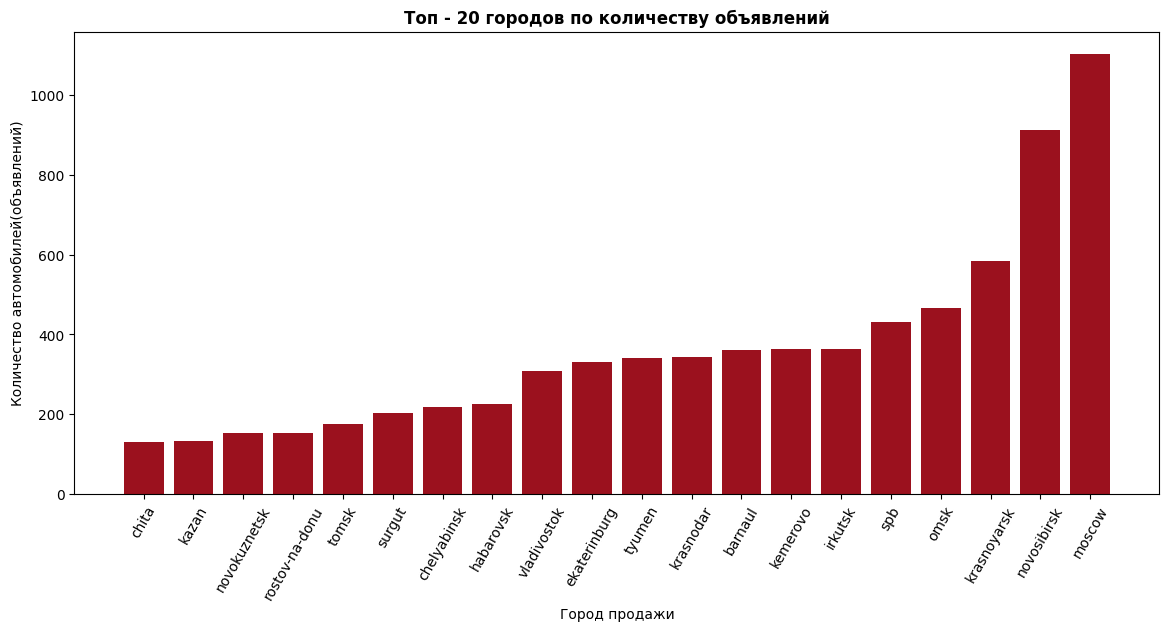

In [376]:
city_pivot = pd.pivot_table(df, values = 'url', index = 'city', aggfunc = 'count')
city_pivot = city_pivot.sort_values(by = 'url').tail(20)
plt.figure(figsize = (14, 6))
plt.bar(city_pivot.index, city_pivot['url'], color = '#9B111E')

plt.title('Топ - 20 городов по количеству объявлений', fontweight = 'bold')
plt.xlabel('Город продажи')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 60)

В лидерах стоят города входящие в топ по населению России. Поэтому у них и наибольшее количество объявлений

# 3.make

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'belgee'),
  Text(1, 0, 'haval'),
  Text(2, 0, 'lada'),
  Text(3, 0, 'changan'),
  Text(4, 0, 'cheryexeed'),
  Text(5, 0, 'chery'),
  Text(6, 0, 'chevrolet'),
  Text(7, 0, 'bmw'),
  Text(8, 0, 'mazda'),
  Text(9, 0, 'ford'),
  Text(10, 0, 'audi'),
  Text(11, 0, 'volkswagen'),
  Text(12, 0, 'mitsubishi'),
  Text(13, 0, 'mercedes-benz'),
  Text(14, 0, 'skoda'),
  Text(15, 0, 'honda'),
  Text(16, 0, 'hyundai'),
  Text(17, 0, 'nissan'),
  Text(18, 0, 'toyota'),
  Text(19, 0, 'lexus'),
  Text(20, 0, 'kia'),
  Text(21, 0, 'renault')])

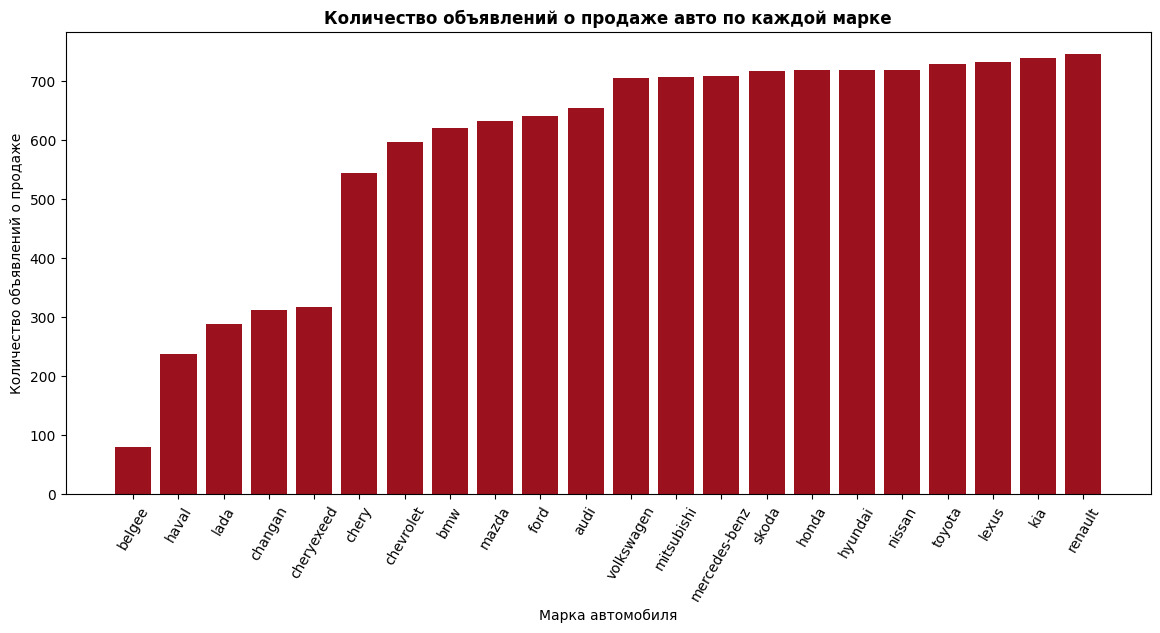

In [377]:
make_pivot = pd.pivot_table(df, values = 'url', index = 'make', aggfunc = 'count').sort_values(by = 'url')


plt.figure(figsize = (14, 6))
plt.bar(make_pivot.index, make_pivot['url'], color = '#9B111E')


plt.title('Количество объявлений о продаже авто по каждой марке', fontweight = 'bold')
plt.xlabel('Марка автомобиля')
plt.ylabel('Количество объявлений о продаже')
plt.xticks(rotation = 60)

В датасете явно больше японцев и немцев, а китайцев и русских сильно меньше

# 4.model

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'belgee'),
  Text(1, 0, 'cheryexeed'),
  Text(2, 0, 'skoda'),
  Text(3, 0, 'haval'),
  Text(4, 0, 'lada'),
  Text(5, 0, 'changan'),
  Text(6, 0, 'renault'),
  Text(7, 0, 'chery'),
  Text(8, 0, 'bmw'),
  Text(9, 0, 'kia'),
  Text(10, 0, 'audi'),
  Text(11, 0, 'mercedes-benz'),
  Text(12, 0, 'ford'),
  Text(13, 0, 'volkswagen'),
  Text(14, 0, 'chevrolet'),
  Text(15, 0, 'mazda'),
  Text(16, 0, 'hyundai'),
  Text(17, 0, 'honda'),
  Text(18, 0, 'mitsubishi'),
  Text(19, 0, 'lexus'),
  Text(20, 0, 'nissan'),
  Text(21, 0, 'toyota')])

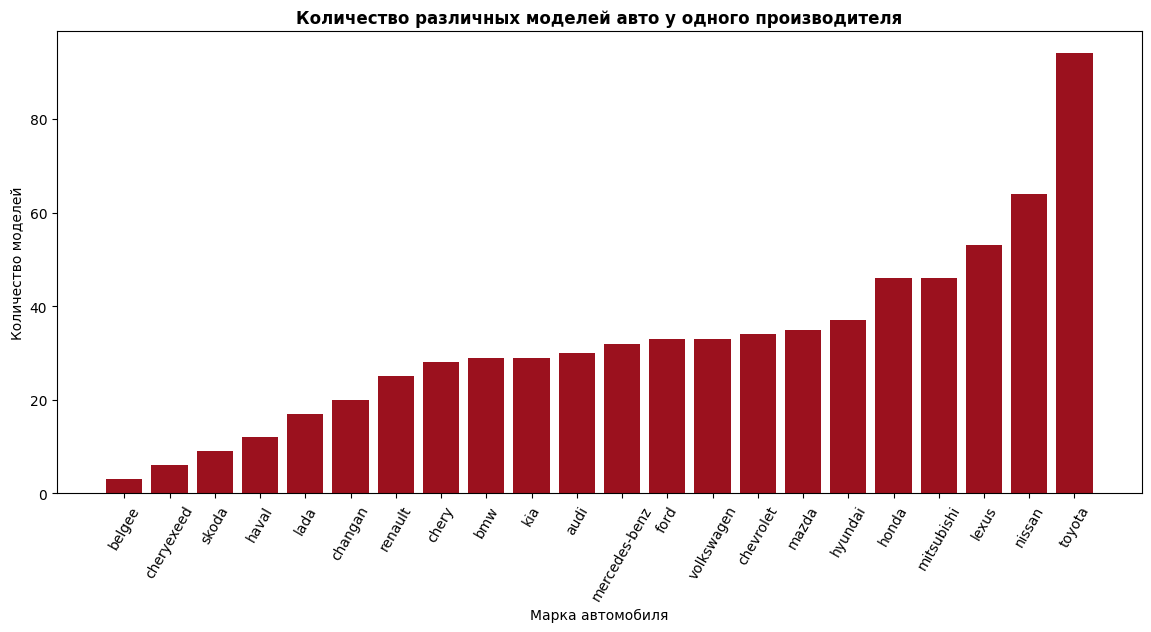

In [378]:
model_pivot = pd.pivot_table(df, values = 'model', index = 'make', aggfunc = 'nunique').sort_values(by = 'model')


plt.figure(figsize = (14, 6))
plt.bar(model_pivot.index, model_pivot['model'], color = '#9B111E')


plt.title('Количество различных моделей авто у одного производителя', fontweight = 'bold')
plt.xlabel('Марка автомобиля')
plt.ylabel('Количество моделей')
plt.xticks(rotation = 60)

Toyota имеет наибольшее количество различных моделей, в то время как belgee наименьшее

# 5.price

In [379]:
price_table = pd.cut(df['price'], bins = [0, 500000, 1000000, 2000000, 4000000, 6000000, 10000000, 20000000, 40000000000000],
    labels = ['до 500.000', '500.000 – 1.000.000', '1.000.000 – 2.000.000', '2.000.000 – 4.000.000', '4.000.000 – 6.000.000',
              '6.000.000 – 10.000.000', '10.000.000 - 20.000.000', '20.000.000+'])
price_table = price_table.value_counts().sort_index()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'до 500.000'),
  Text(1, 0, '500.000 – 1.000.000'),
  Text(2, 0, '1.000.000 – 2.000.000'),
  Text(3, 0, '2.000.000 – 4.000.000'),
  Text(4, 0, '4.000.000 – 6.000.000'),
  Text(5, 0, '6.000.000 – 10.000.000'),
  Text(6, 0, '10.000.000 - 20.000.000'),
  Text(7, 0, '20.000.000+')])

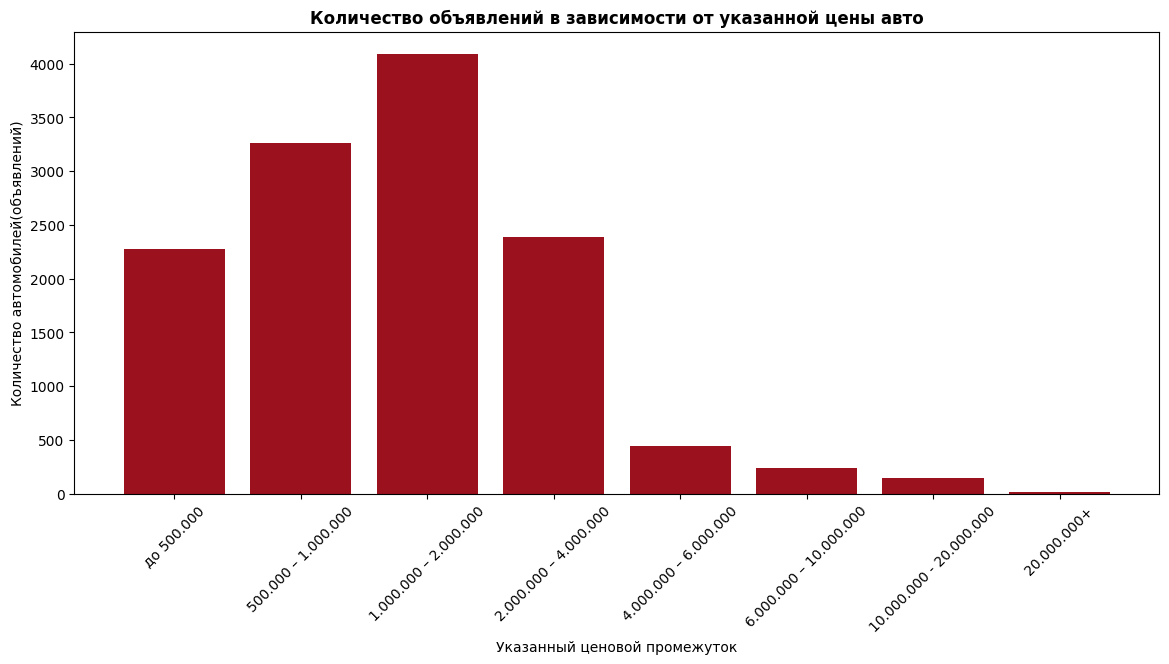

In [380]:
plt.figure(figsize = (14, 6))
plt.bar(price_table.index, price_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от указанной цены авто', fontweight = 'bold')
plt.xlabel('Указанный ценовой промежуток')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

Выборка смещена больше к нулю, то есть у нас в датасете больше дешевых, чем дорогих машин. При этом пик стоимости - это от 1 до 2 млн

# 6.price_badge

In [381]:
df['price_badge'].unique()

array(['хорошая', 'нормальная', 'высокая', 'без оценки', 'отличная'],
      dtype=object)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'без оценки'),
  Text(1, 0, 'высокая'),
  Text(2, 0, 'нормальная'),
  Text(3, 0, 'отличная'),
  Text(4, 0, 'хорошая')])

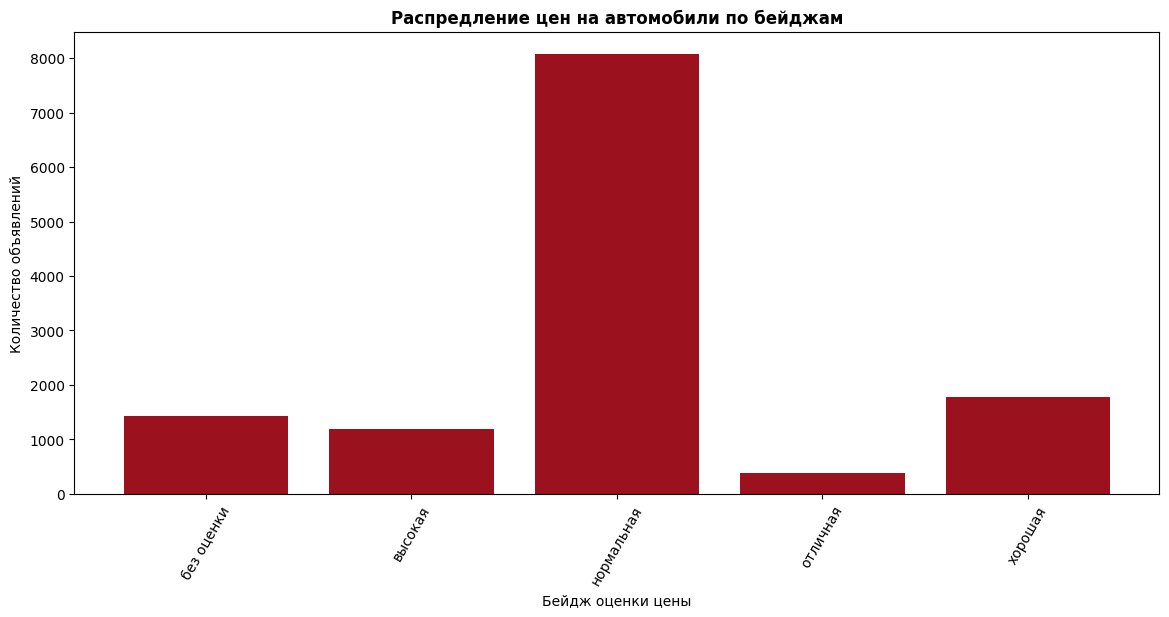

In [382]:
badge_pivot = pd.pivot_table(df, values = 'url', index = 'price_badge', aggfunc = 'count')

plt.figure(figsize = (14, 6))
plt.bar(badge_pivot.index, badge_pivot['url'], color = '#9B111E')


plt.title('Распредление цен на автомобили по бейджам', fontweight = 'bold')
plt.xlabel('Бейдж оценки цены')
plt.ylabel('Количество объявлений')
plt.xticks(rotation = 60)

Чаще всего цена оценивается как "нормальная"

# 7.published_date

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, '05.05.2026'),
  Text(1, 0, '06.04.2026'),
  Text(2, 0, '06.05.2026'),
  Text(3, 0, '07.04.2026'),
  Text(4, 0, '07.05.2026'),
  Text(5, 0, '08.05.2026'),
  Text(6, 0, '09.05.2026'),
  Text(7, 0, '10.05.2026'),
  Text(8, 0, '11.05.2026'),
  Text(9, 0, '12.05.2026'),
  Text(10, 0, '13.05.2026'),
  Text(11, 0, '14.05.2026'),
  Text(12, 0, '15.04.2026'),
  Text(13, 0, '15.05.2026'),
  Text(14, 0, '16.05.2026'),
  Text(15, 0, '17.05.2026'),
  Text(16, 0, '18.05.2026'),
  Text(17, 0, '19.05.2026'),
  Text(18, 0, '20.05.2026'),
  Text(19, 0, '21.05.2026'),
  Text(20, 0, '22.05.2026'),
  Text(21, 0, '23.05.2026'),
  Text(22, 0, '26.04.2026'),
  Text(23, 0, '28.04.2026'),
  Text(24, 0, '29.03.2026')])

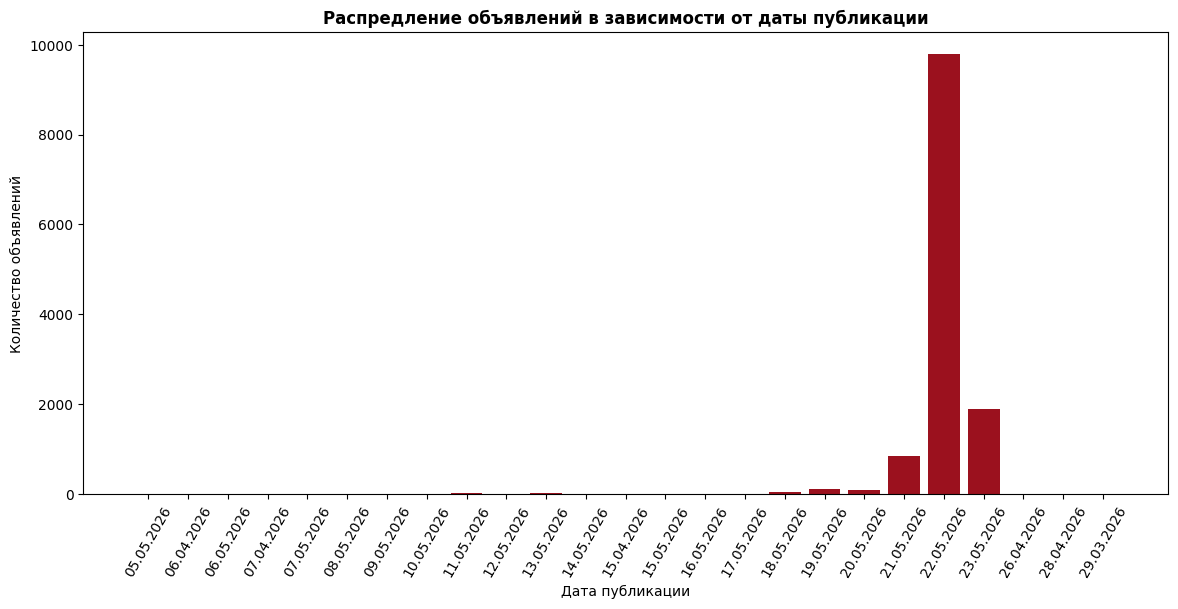

In [383]:
date_pivot = pd.pivot_table(df, values = 'url', index = 'published_date', aggfunc = 'count')

df['published_date'] = pd.to_datetime(df['published_date'], format = '%d.%m.%Y')
date_pivot = date_pivot.sort_index()

plt.figure(figsize = (14, 6))
plt.bar(date_pivot.index, date_pivot['url'], color = '#9B111E')


plt.title('Распредление объявлений в зависимости от даты публикации', fontweight = 'bold')
plt.xlabel('Дата публикации')
plt.ylabel('Количество объявлений')
plt.xticks(rotation = 60)

В датасете преимущественно новые объявления

# 8.engine

In [384]:
df['engine'].unique()

array(['бензин, 2.0 л', 'бензин, 1.6 л', 'бензин, 1.0 л', 'бензин, 1.4 л',
       'дизель, 2.2 л', 'бензин, 2.4 л', 'бензин, 1.5 л', 'бензин, 1.8 л',
       'бензин, 2.5 л', 'дизель, 2.5 л', 'бензин, 2.5 л, ГБО',
       'бензин, 4.0 л', 'бензин, 2.7 л', 'бензин, 5.7 л', 'бензин, 3.5 л',
       'бензин, 1.6 л, ГБО', 'бензин, 1.8 л, гибрид', 'дизель, 3.0 л',
       'бензин, 2.7 л, ГБО', 'дизель, 2.8 л', 'дизель, 2.0 л',
       'бензин, 2.4 л, ГБО', 'бензин, 3.3 л', 'бензин, 3.0 л',
       'дизель, 4.5 л', 'бензин, 2.5 л, гибрид', 'бензин, 3.4 л, гибрид',
       'бензин, 1.3 л', 'бензин, 3.0 л, ГБО', 'бензин, 5.0 л',
       'дизель, 1.4 л', 'бензин, 2.0 л, ГБО', 'бензин, 1.2 л',
       'бензин, 4.6 л', 'бензин, 1.5 л, гибрид', 'бензин, 1.4 л, ГБО',
       'бензин, 3.5 л, ГБО', 'дизель, 2.4 л', 'дизель, 4.2 л',
       '2.5 л, гибрид', 'бензин, 1.1 л', 'бензин, 3.4 л',
       'бензин, 1.5 л, гибрид, ГБО', 'дизель, 3.3 л',
       'бензин, 1.5 л, ГБО', 'бензин, 4.7 л', 'дизель, 1.6 л',
      

Необходимо реализовать feature engineering для этого признака, чтобы дальше можно было корректно работать

In [385]:
split_engine = df['engine'].str.split(',', expand = True)
df['oil_type'] = split_engine[0]
df['engine_volume'] = split_engine[1]
df = df.drop('engine', axis = 1)

In [386]:
oil_table = df['oil_type'].value_counts()
oil_table

,count
oil_type,
бензин,11697
дизель,1125
электро,22
2.5 л,3
2.4 л,2
3.5 л,2
3.0 л,2
2.0 л,2
1.5 л,1


In [387]:
df = df[df['oil_type'].isin(['бензин', 'дизель', 'электро'])]
oil_table = df['oil_type'].value_counts()
oil_table

,count
oil_type,
бензин,11697
дизель,1125
электро,22


Text(0, 0.5, 'Количество объявлений')

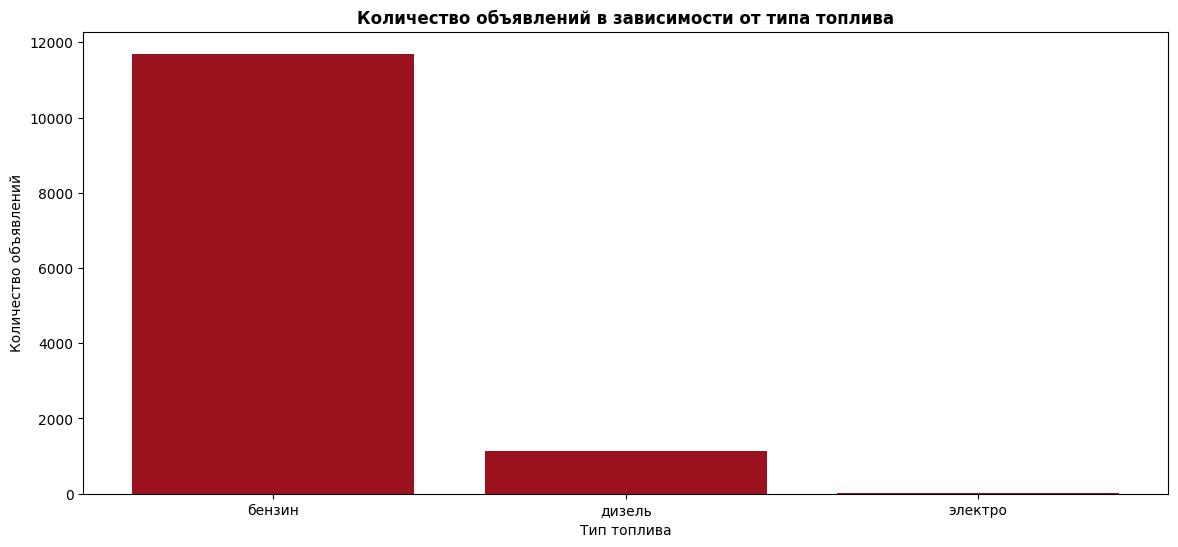

In [388]:
plt.figure(figsize = (14, 6))
plt.bar(oil_table.index, oil_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от типа топлива', fontweight = 'bold')
plt.xlabel('Тип топлива')
plt.ylabel('Количество объявлений')

Больше всего в датасете представлено бензиновых авто, практически не представлены электромобили

In [389]:
volume_table = df['engine_volume'].value_counts().sort_index()
volume_table

,count
engine_volume,
0.1 л,1
0.6 л,3
0.7 л,61
0.8 л,10
1.0 л,85
1.1 л,15
1.2 л,202
1.3 л,329
1.4 л,780


In [390]:
df['engine_volume'] = df['engine_volume'].str.strip().str[:3].astype(float)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51],
 [Text(0, 0, ' 0.1 л'),
  Text(1, 0, ' 0.6 л'),
  Text(2, 0, ' 0.7 л'),
  Text(3, 0, ' 0.8 л'),
  Text(4, 0, ' 1.0 л'),
  Text(5, 0, ' 1.1 л'),
  Text(6, 0, ' 1.2 л'),
  Text(7, 0, ' 1.3 л'),
  Text(8, 0, ' 1.4 л'),
  Text(9, 0, ' 1.5 л'),
  Text(10, 0, ' 1.6 л'),
  Text(11, 0, ' 1.7 л'),
  Text(12, 0, ' 1.8 л'),
  Text(13, 0, ' 1.9 л'),
  Text(14, 0, ' 2.0 л'),
  Text(15, 0, ' 2.1 л'),
  Text(16, 0, ' 2.2 л'),
  Text(17, 0, ' 2.3 л'),
  Text(18, 0, ' 2.4 л'),
  Text(19, 0, ' 2.5 л'),
  Text(20, 0, ' 2.6 л'),
  Text(21, 0, ' 2.7 л'),
  Text(22, 0, ' 2.8 л'),
  Text(23, 0, ' 2.9 л'),
  Text(24, 0, ' 3.0 л'),
  Text(25, 0, ' 3.1 л'),
  Text(26, 0, ' 3.2 л'),
  Text(27, 0, ' 3.3 л'),
  Text(

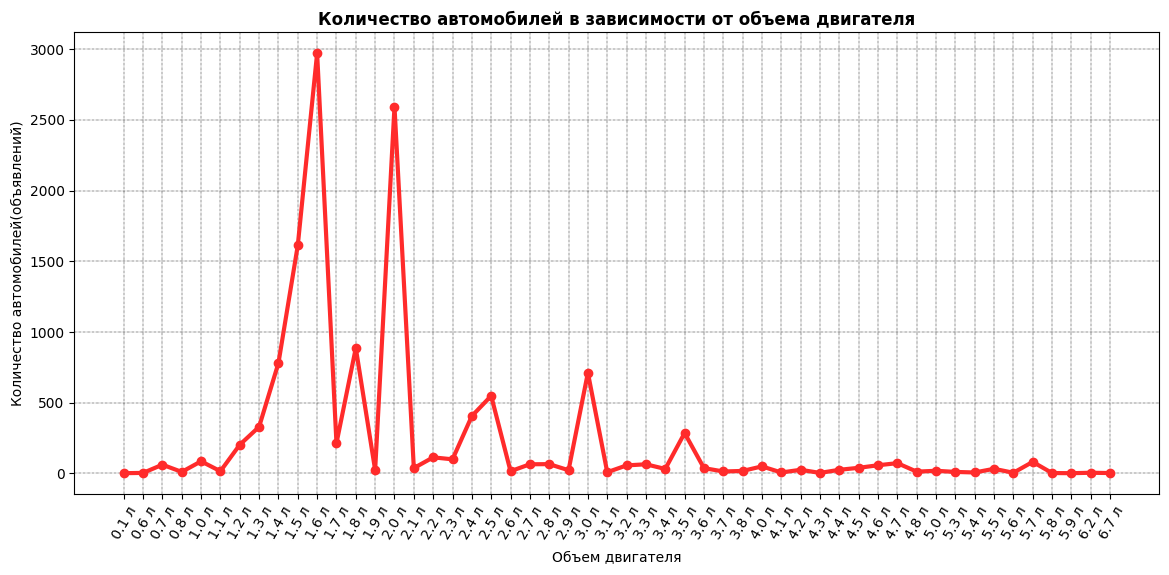

In [391]:
plt.figure(figsize = (14, 6))

plt.plot(volume_table.index, volume_table, color = '#FF2B2B', linewidth = 3, marker = 'o')
plt.grid(axis = 'both', color = 'black', linestyle = '-.', linewidth = 0.3)
plt.title('Количество автомобилей в зависимости от объема двигателя', fontweight = 'bold')
plt.xlabel('Объем двигателя')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 60)


Больше всего 1.6 и 2.0 литра объем двигателя

# 9.transmission

In [392]:
df = df[df['transmission'] != '- Переключение крутящего момента – “TorqShift- G” – 10 cкоростей']

In [393]:
df.loc[df['transmission'] == 'автомат', 'transmission'] = 'АКПП'

In [394]:
transmission_table = pd.pivot_table(df, values = 'url', index = 'transmission', aggfunc = 'count')
transmission_table

,url
transmission,
АКПП,6115
вариатор,1859
механика,2964
робот,1905


Text(0, 0.5, 'Количество автомобилей(объявлений)')

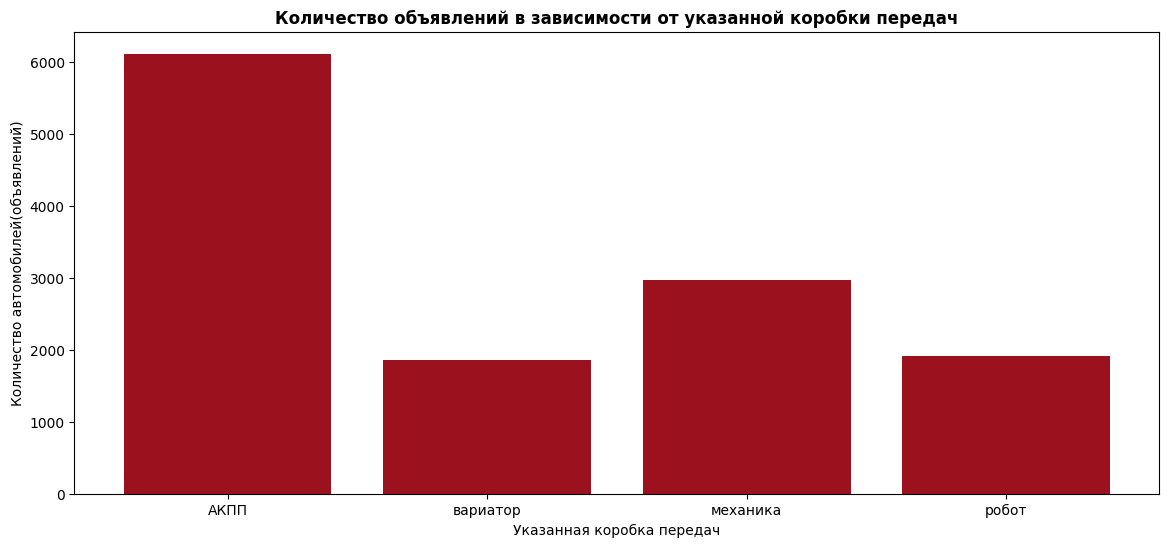

In [395]:

plt.figure(figsize = (14, 6))
plt.bar(transmission_table.index, transmission_table['url'], color = '#9B111E')

plt.title('Количество объявлений в зависимости от указанной коробки передач', fontweight = 'bold')
plt.xlabel('Указанная коробка передач')
plt.ylabel('Количество автомобилей(объявлений)')

Больше всего в датасете машин на АКПП, меньше всего на вариаторе или роботе

# 10.mileage

In [396]:
mileage_table = pd.cut(df['mileage'], bins = [0, 10000, 30000, 50000, 100000, 150000, 200000, 300000, 400000, 600000, 1000000],
    labels = ['до 10.000', '10.000 - 30.000', '30.000 - 50.000', '50.000 – 100.000', '100.000 – 150.000', '150.000 – 200.000', '200.000 – 300.000',
              '300.000 – 400.000', '400.000 - 600.000', '600000+'])
mileage_table = mileage_table.value_counts().sort_index()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'до 10.000'),
  Text(1, 0, '10.000 - 30.000'),
  Text(2, 0, '30.000 - 50.000'),
  Text(3, 0, '50.000 – 100.000'),
  Text(4, 0, '100.000 – 150.000'),
  Text(5, 0, '150.000 – 200.000'),
  Text(6, 0, '200.000 – 300.000'),
  Text(7, 0, '300.000 – 400.000'),
  Text(8, 0, '400.000 - 600.000'),
  Text(9, 0, '600000+')])

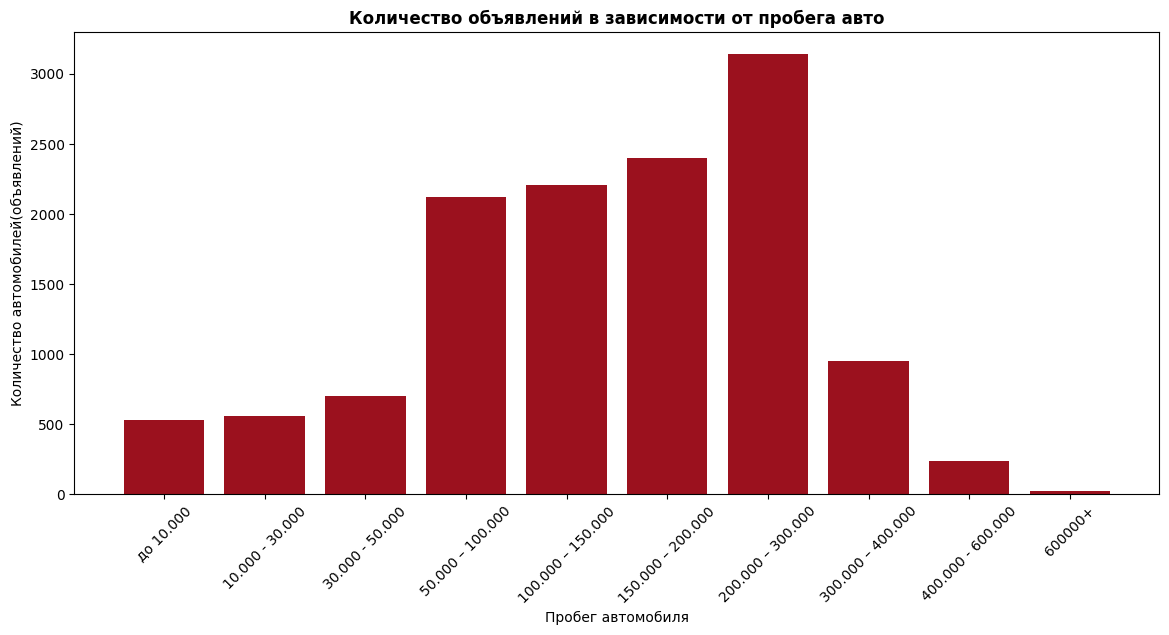

In [397]:
plt.figure(figsize = (14, 6))
plt.bar(mileage_table.index, mileage_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от пробега авто', fontweight = 'bold')
plt.xlabel('Пробег автомобиля')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

Чаще всего машины с пробегом от 50.000 до 300.000. При этом пик количества объявлений с машинами с пробегом от 200.000 до 300.000

# 11.drive

([0, 1, 2], [Text(0, 0, '4WD'), Text(1, 0, 'задний'), Text(2, 0, 'передний')])

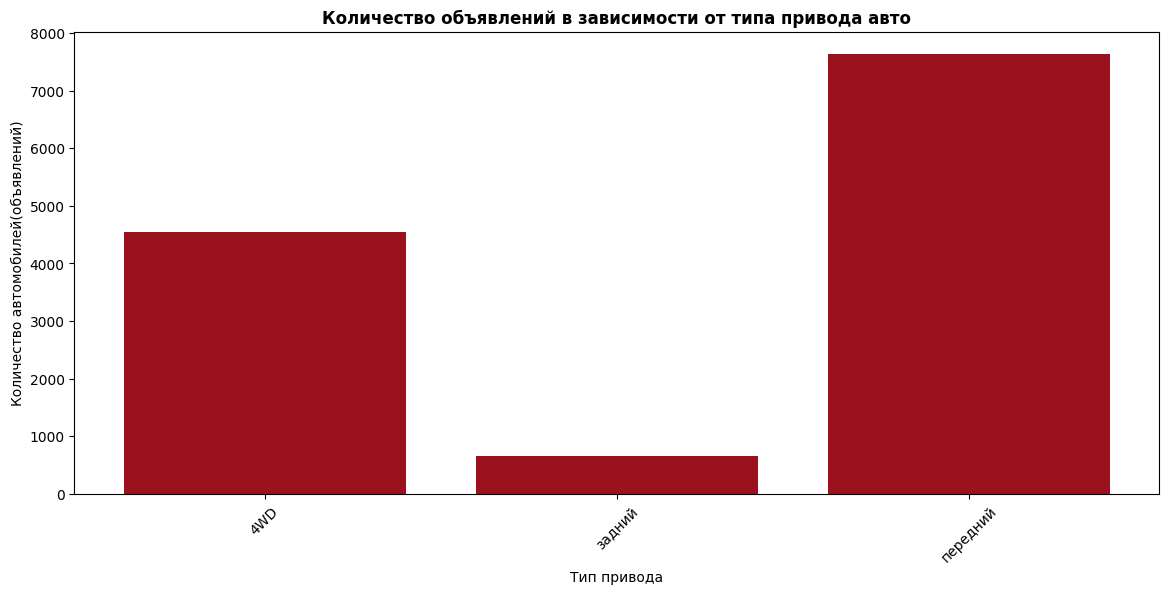

In [398]:
drive_pivot = pd.pivot_table(df, values = 'url', index = 'drive', aggfunc = 'count')
plt.figure(figsize = (14, 6))
plt.bar(drive_pivot.index, drive_pivot['url'], color = '#9B111E')

plt.title('Количество объявлений в зависимости от типа привода авто', fontweight = 'bold')
plt.xlabel('Тип привода')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

Больше всего машин с передним приводом

# 12.color

In [399]:
color_table = df['color'].value_counts()
color_table

,count
color,
белый,3247
черный,2820
серый,2432
серебристый,1142
синий,1022
красный,552
коричневый,454
зеленый,333
бежевый,258


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'белый'),
  Text(1, 0, 'черный'),
  Text(2, 0, 'серый'),
  Text(3, 0, 'серебристый'),
  Text(4, 0, 'синий'),
  Text(5, 0, 'красный'),
  Text(6, 0, 'коричневый'),
  Text(7, 0, 'зеленый'),
  Text(8, 0, 'бежевый'),
  Text(9, 0, 'голубой'),
  Text(10, 0, 'бордовый'),
  Text(11, 0, 'фиолетовый'),
  Text(12, 0, 'золотистый'),
  Text(13, 0, 'оранжевый'),
  Text(14, 0, 'желтый'),
  Text(15, 0, 'розовый')])

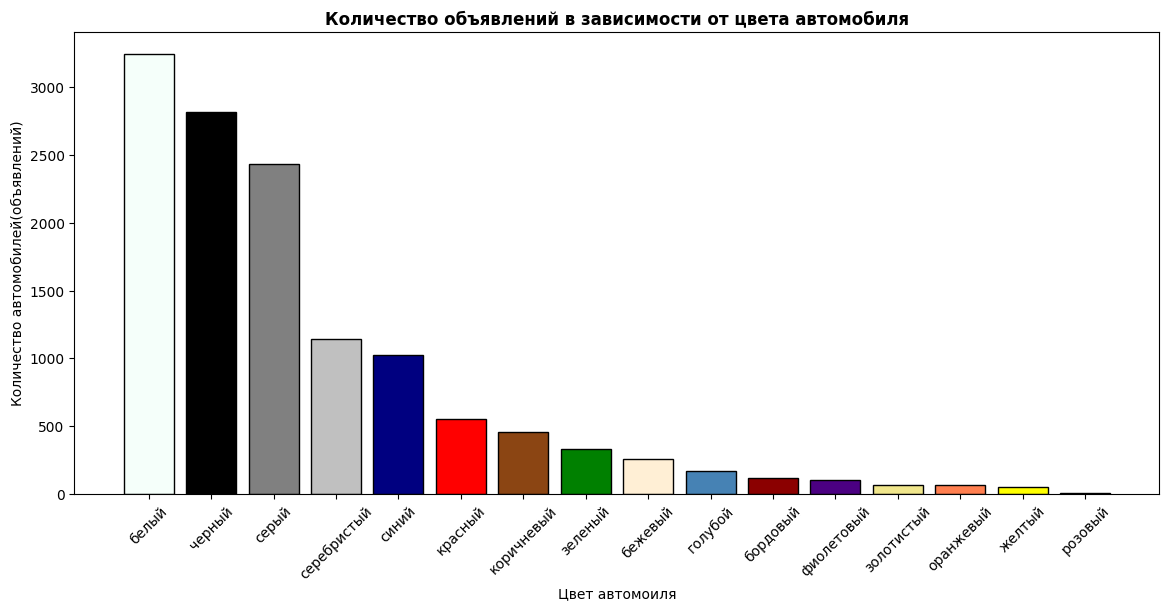

In [400]:
plt.figure(figsize = (14, 6))
plt.bar(color_table.index, color_table, color = ['#F5FFFA','#000000', '#808080', '#C0C0C0','#000080', '#FF0000','#8B4513',
                                                '#008000', '#FFEFD5', '#4682B4' , '#8B0000', '#4B0082', '#F0E68C', '#FF7F50',
                                                '#FFFF00', '#FF69B4'], edgecolor = 'black', linewidth = 1)

plt.title('Количество объявлений в зависимости от цвета автомобиля', fontweight = 'bold')
plt.xlabel('Цвет автомоиля')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

Больше объявлений с базовыми ч/б цветами

# 13.wheel

In [401]:
df = df[df['wheel'] != 'Приборка стоит от реста']

Text(0.5, 1.0, 'Количество автомобилей в зависимости от расположения руля')

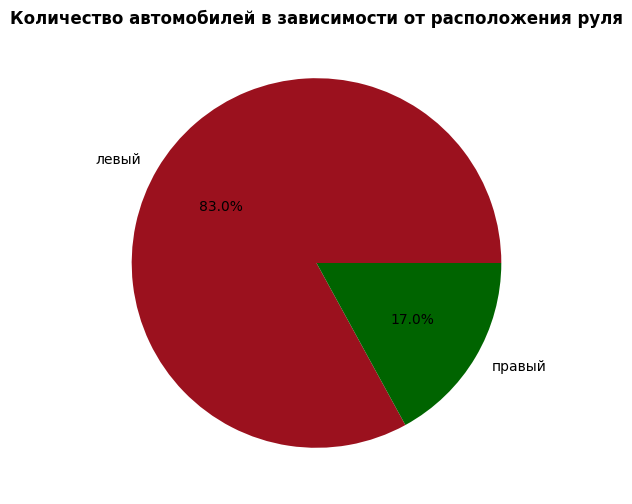

In [402]:
wheel_table = df['wheel'].value_counts()
plt.figure(figsize = (14, 6))
colors = ['#9B111E', '#006400']
plt.pie(wheel_table, labels = wheel_table.index, colors = colors, autopct = '%.1f%%')
plt.title('Количество автомобилей в зависимости от расположения руля', fontweight = 'bold')

Чаще представлены леворульные машины. Это нормально для россии, так как тут левосторонее движение

# 14.hp

In [403]:
gp_table = pd.cut(df['hp'], bins = [0, 80, 110, 156, 200, 252, 300, 500, 2000],
    labels = ['до 80', '80 - 110', '110 - 156', '156 - 200', '200 – 252', '252 - 300', '300 - 500',
              '500+'])
gp_table = gp_table.value_counts().sort_index()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'до 80'),
  Text(1, 0, '80 - 110'),
  Text(2, 0, '110 - 156'),
  Text(3, 0, '156 - 200'),
  Text(4, 0, '200 – 252'),
  Text(5, 0, '252 - 300'),
  Text(6, 0, '300 - 500'),
  Text(7, 0, '500+')])

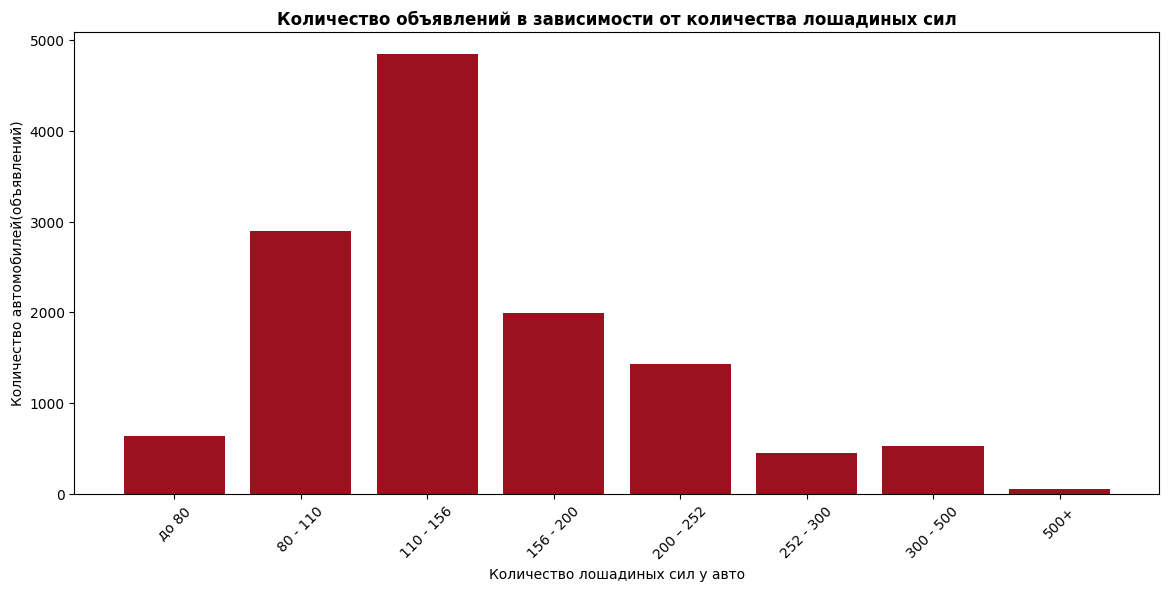

In [404]:
plt.figure(figsize = (14, 6))
plt.bar(gp_table.index, gp_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от количества лошадиных сил', fontweight = 'bold')
plt.xlabel('Количество лошадиных сил у авто')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

В основном у машин от 80 до 200 лошадиных сил. Наибольшее количество авто имеет 110-156

# 15.seller_type

Text(0.5, 1.0, 'Количество автомобилей в зависимости от типа продавца')

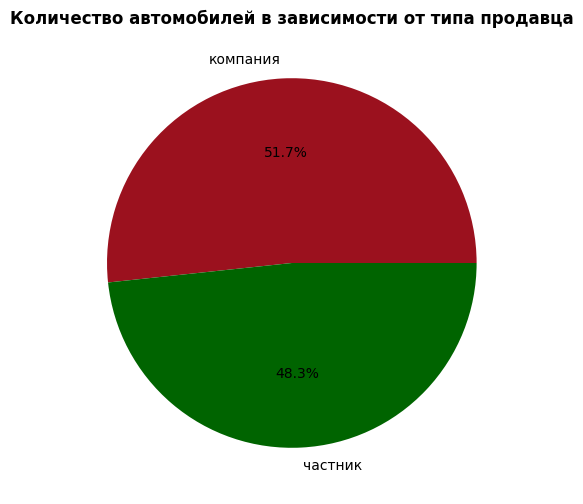

In [405]:
wheel_table = df['seller_type'].value_counts()
plt.figure(figsize = (14, 6))
colors = ['#9B111E', '#006400']
plt.pie(wheel_table, labels = wheel_table.index, colors = colors, autopct = '%.1f%%')
plt.title('Количество автомобилей в зависимости от типа продавца', fontweight = 'bold')

У нас практически одинаково распределены частники и компании

# 16.owner_status

Text(0.5, 1.0, 'Количество автомобилей в зависимости от статуса продавца')

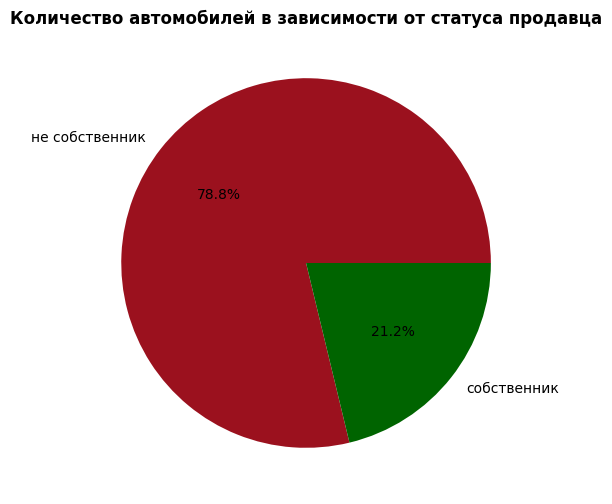

In [406]:
wheel_table = df['owner_status'].value_counts()
plt.figure(figsize = (14, 6))
colors = ['#9B111E', '#006400']
plt.pie(wheel_table, labels = wheel_table.index, colors = colors, autopct = '%.1f%%')
plt.title('Количество автомобилей в зависимости от статуса продавца', fontweight = 'bold')

В нашем датасете большее количество машин не от собственников

# Multivaruant анализ

# Медианная цена в зависимости от марки автомобиля

In [407]:
median_make = pd.pivot_table(df,values = 'price', index = 'make', aggfunc = 'median')


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'chevrolet'),
  Text(1, 0, 'ford'),
  Text(2, 0, 'lada'),
  Text(3, 0, 'renault'),
  Text(4, 0, 'mitsubishi'),
  Text(5, 0, 'nissan'),
  Text(6, 0, 'honda'),
  Text(7, 0, 'mazda'),
  Text(8, 0, 'skoda'),
  Text(9, 0, 'hyundai'),
  Text(10, 0, 'volkswagen'),
  Text(11, 0, 'toyota'),
  Text(12, 0, 'kia'),
  Text(13, 0, 'chery'),
  Text(14, 0, 'audi'),
  Text(15, 0, 'belgee'),
  Text(16, 0, 'haval'),
  Text(17, 0, 'mercedes-benz'),
  Text(18, 0, 'changan'),
  Text(19, 0, 'bmw'),
  Text(20, 0, 'cheryexeed'),
  Text(21, 0, 'lexus')])

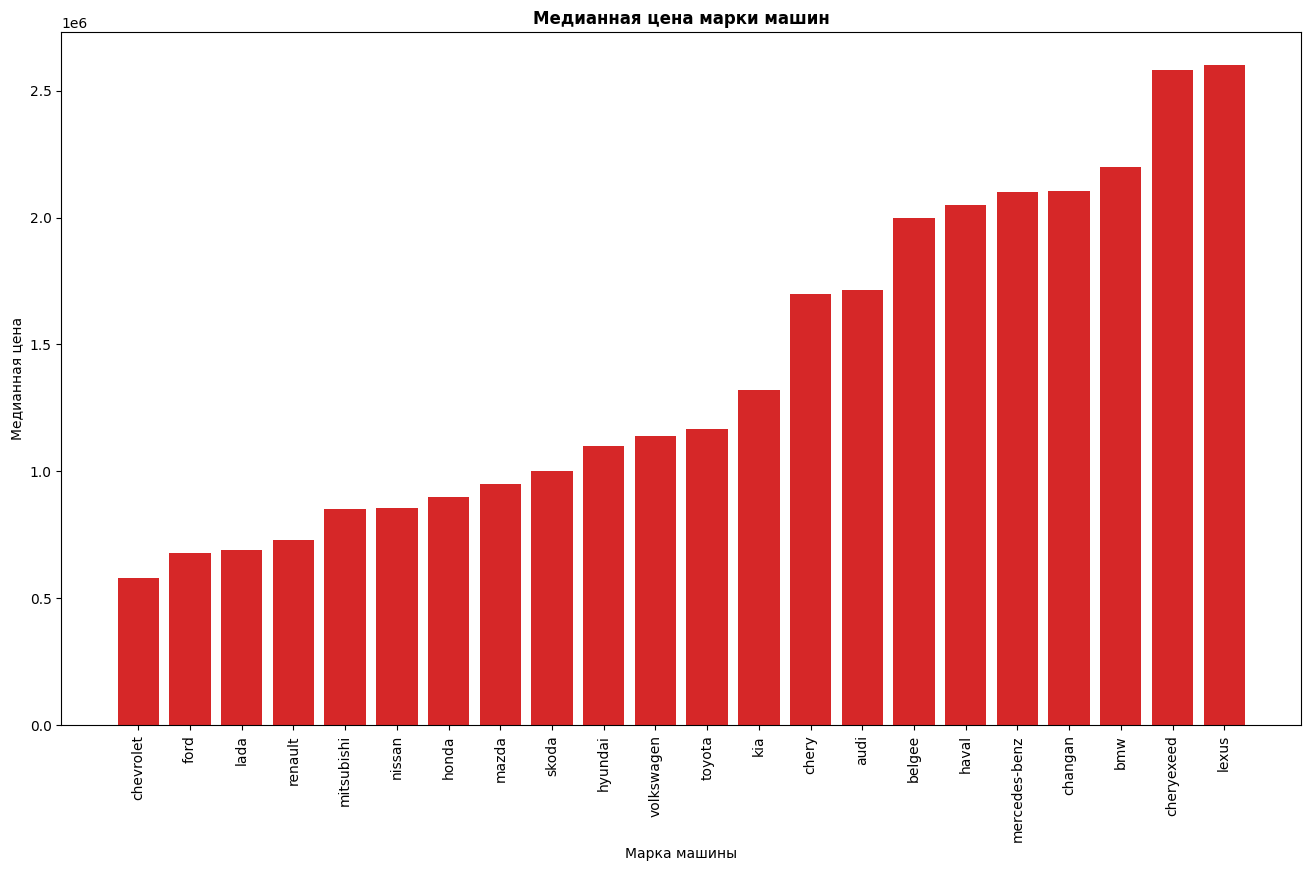

In [408]:
median_make = median_make.sort_values(by = 'price')
plt.figure(figsize = (16, 9))
plt.bar(median_make.index, median_make['price'], color = '#D62728')

plt.title('Медианная цена марки машин',fontweight = 'bold')
plt.xlabel('Марка машины')
plt.ylabel('Медианная цена')
plt.xticks(rotation = 90)

cherryexeed и lexus имеют самую высокую медианную цену в выборке

# Цена в зависимости от цвета

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'бордовый'),
  Text(1, 0, 'розовый'),
  Text(2, 0, 'голубой'),
  Text(3, 0, 'зеленый'),
  Text(4, 0, 'желтый'),
  Text(5, 0, 'серебристый'),
  Text(6, 0, 'золотистый'),
  Text(7, 0, 'бежевый'),
  Text(8, 0, 'красный'),
  Text(9, 0, 'синий'),
  Text(10, 0, 'фиолетовый'),
  Text(11, 0, 'оранжевый'),
  Text(12, 0, 'серый'),
  Text(13, 0, 'коричневый'),
  Text(14, 0, 'черный'),
  Text(15, 0, 'белый')])

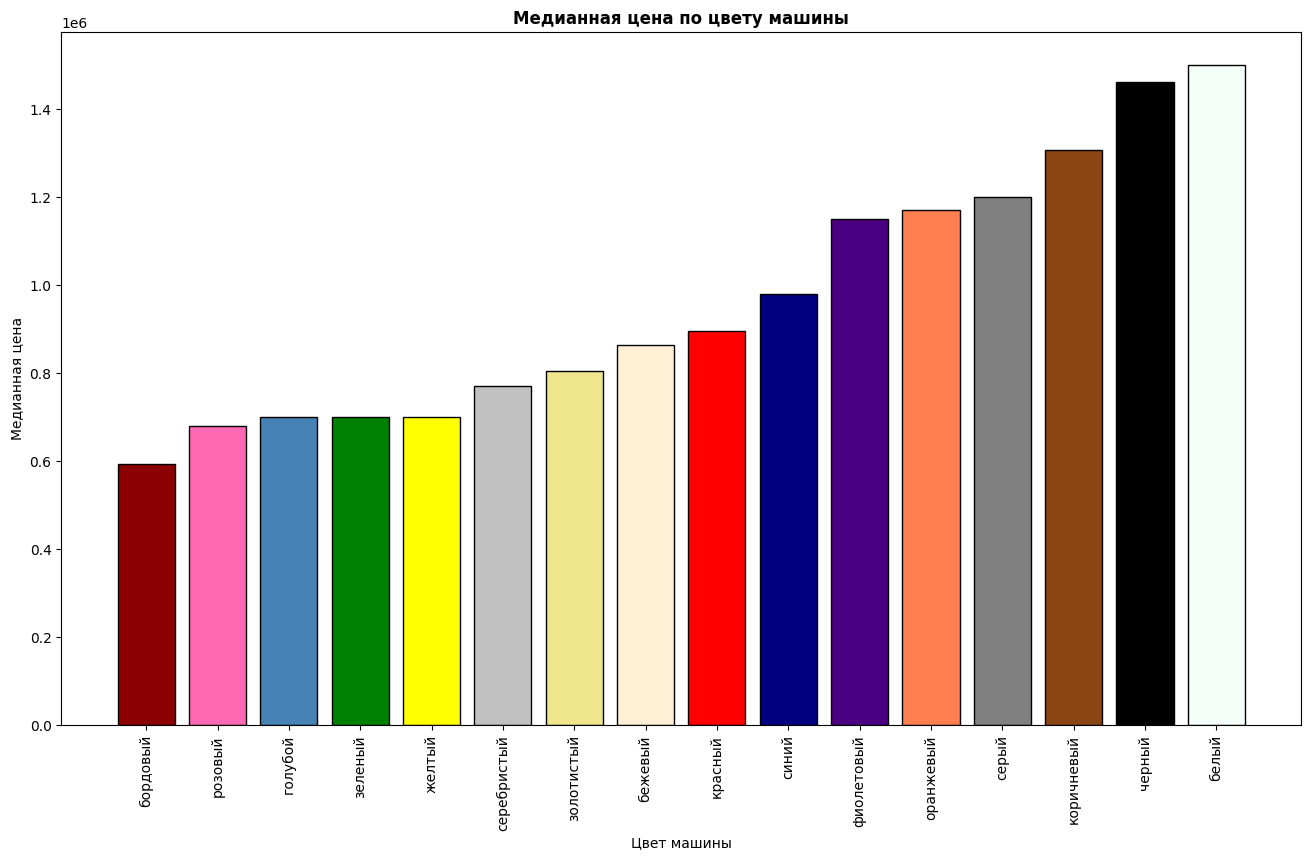

In [409]:
median_clr = pd.pivot_table(df,values = 'price', index = 'color', aggfunc = 'median')
median_clr = median_clr.sort_values(by = 'price')
plt.figure(figsize = (16, 9))
plt.bar(median_clr.index, median_clr['price'], color = ['#8B0000','#FF69B4','#4682B4', '#008000', '#FFFF00',
                                                        '#C0C0C0', '#F0E68C', '#FFEFD5', '#FF0000', '#000080',
                                                        '#4B0082', '#FF7F50', '#808080', '#8B4513', '#000000',
                                                         '#F5FFFA'], edgecolor = 'black', linewidth = 1)

plt.title('Медианная цена по цвету машины',fontweight = 'bold')
plt.xlabel('Цвет машины')
plt.ylabel('Медианная цена')
plt.xticks(rotation = 90)


Базовые цвета все еще имебт большую медианную стоимость

# Цена в зависимости от года выпуска

Text(0, 0.5, 'Медианная цена')

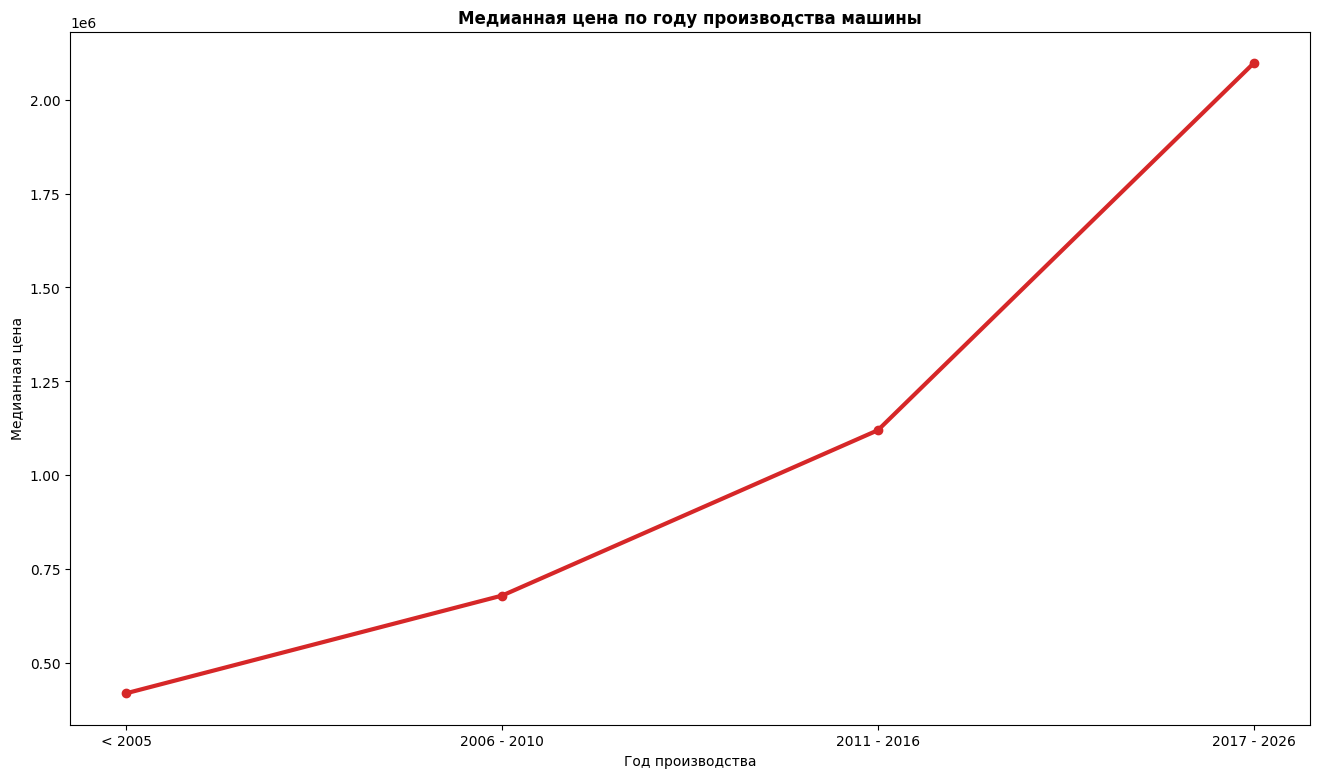

In [410]:
df['year'].value_counts().sort_values()
less_2005 = [1982,1983,1984,1985,1986, 1987,1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005]


from_2006_to_2010 = [2006, 2007, 2008,2009,2010]

from_2011_to_2016 = [2011, 2012, 2013, 2014, 2015, 2016]

from_2017_to_2026 = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

df.loc[df['year'].isin(less_2005), 'car_year'] = '< 2005'
df.loc[df['year'].isin(from_2006_to_2010), 'car_year'] = '2006 - 2010'
df.loc[df['year'].isin(from_2011_to_2016), 'car_year'] = '2011 - 2016'
df.loc[df['year'].isin(from_2017_to_2026), 'car_year'] = '2017 - 2026'

year_category_pivot = pd.pivot_table(df, values = 'price', index = 'car_year', aggfunc = 'median')

order = ['< 2005', '2006 - 2010', '2011 - 2016', '2017 - 2026']
year_category_pivot = year_category_pivot.reindex(order)

plt.figure(figsize=(16, 9))
plt.plot(year_category_pivot.index, year_category_pivot['price'], color = '#D62728', marker='o',linewidth=3 )

plt.title('Медианная цена по году производства машины',fontweight = 'bold')
plt.xlabel('Год производства')
plt.ylabel('Медианная цена')

Более новые машины более дорогие. Цена машины активно растет с увеличением года выпуска

# Цена на авто в зависимости от города объявления

In [411]:
popular_car = pd.pivot_table(df, values = 'url', index = ['make', 'model', 'year'], aggfunc = 'count').sort_values(by = 'url')
popular_car

url
make       model           year       
volkswagen touareg         2017.0    1
audi       a3              2004.0    1
           a1              2015.0    1
                           2014.0    1
                           2013.0    1
...                                ...
belgee     x50             2024.0   42
skoda      octavia         2013.0   46
cheryexeed rx              2023.0   47
ford       focus           2012.0   52
chery      tiggo_7_pro_max 2023.0   64

[3740 rows x 1 columns]

 Будем смотреть в разрезе самой популярной машины тут - это chery tiggo 2023 года

In [412]:
df.head(1)

,url,year,city,make,model,price,price_badge,published_date,transmission,mileage,drive,color,wheel,hp,seller_type,owner_status,is_owner,oil_type,engine_volume,car_year
0,https://auto.drom.ru/kemerovo/kia/sportage/687...,2019.0,kemerovo,kia,sportage,2099000.0,хорошая,2026-05-22,АКПП,66000.0,передний,белый,левый,150.0,частник,собственник,True,бензин,2.0,2017 - 2026


In [413]:
df_chery = df[(df['make'] == 'chery') & (df['model'] == 'tiggo_7_pro_max') & (df['year'] == 2023.0)]
df_chery.loc[~df_ford['city'].isin(['moscow', 'spb']),'city'] = 'region'
city_pivot = pd.pivot_table(df_chery, values = 'price', index = 'city', aggfunc = 'median')
city_pivot


,price
city,
moscow,1899500.0
region,1899500.0
spb,1598475.0


([0, 1, 2], [Text(0, 0, 'moscow'), Text(1, 0, 'region'), Text(2, 0, 'spb')])

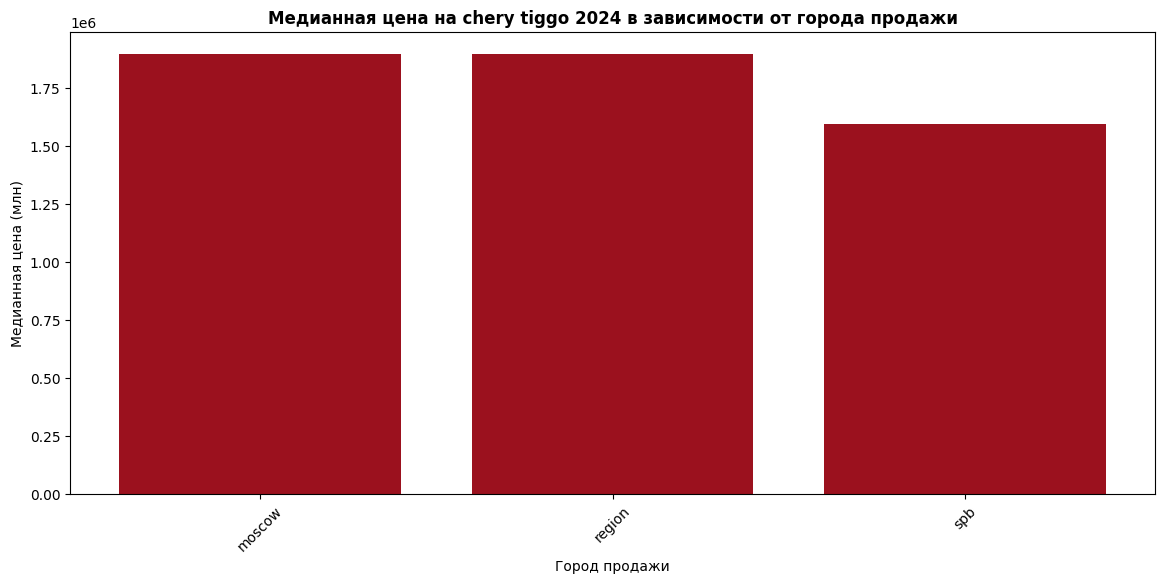

In [414]:
plt.figure(figsize = (14, 6))
plt.bar(city_pivot.index, city_pivot['price'], color = '#9B111E')

plt.title('Медианная цена на chery tiggo 2024 в зависимости от города продажи', fontweight = 'bold')
plt.xlabel('Город продажи')
plt.ylabel('Медианная цена (млн)')
plt.xticks(rotation = 45)

По этой модели дороже всего в регионах, но это происходит так как отдаленные города могут завышать цены из-за сложной логистики доставки автомобилей

# Цена авто в зависимости от типа продавца

In [418]:
df_oktavia = df[(df['make'] == 'skoda') & (df['model'] == 'octavia') & (df['year'] == 2013.0)]


In [419]:
octavia_pivot = pd.pivot_table(df_oktavia, values = 'price', index = 'seller_type', aggfunc = 'median')

([0, 1], [Text(0, 0, 'компания'), Text(1, 0, 'частник')])

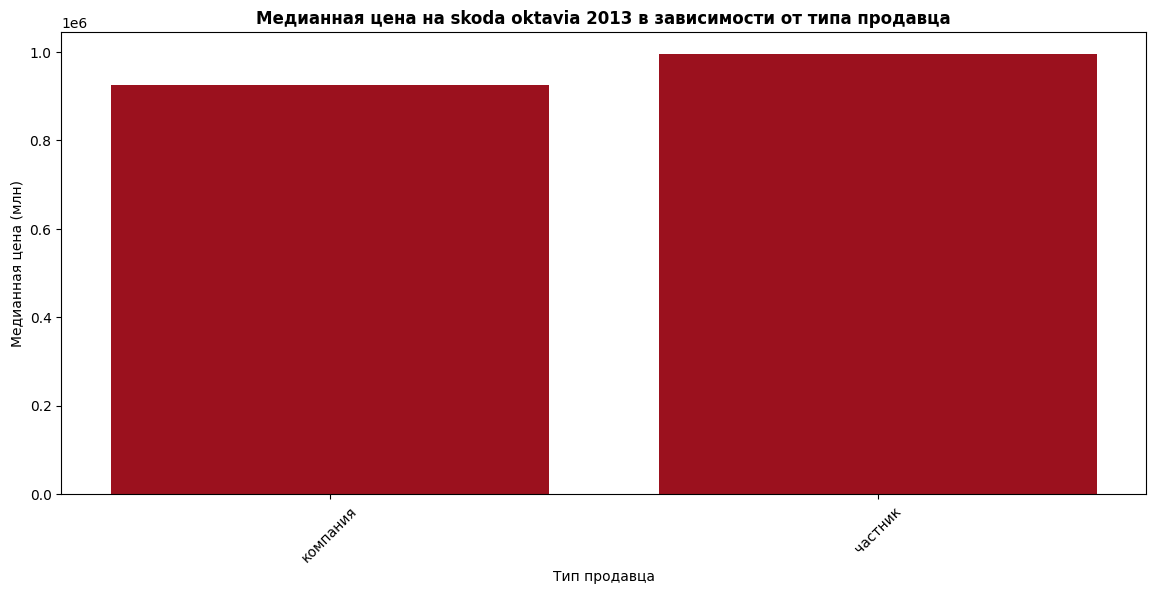

In [420]:
plt.figure(figsize = (14, 6))
plt.bar(octavia_pivot.index, octavia_pivot['price'], color = '#9B111E')

plt.title('Медианная цена на skoda oktavia 2013 в зависимости от типа продавца', fontweight = 'bold')
plt.xlabel('Тип продавца')
plt.ylabel('Медианная цена (млн)')
plt.xticks(rotation = 45)

# Оценка цены авто в зависимости от типа продавца

In [433]:
price_df = df[df['price_badge'] != 'без оценки']

In [434]:
price_df_owner = price_df[price_df['owner_status'] == 'собственник']

In [439]:
price_df_not_owner = price_df[price_df['owner_status'] == 'не собс твенник']

In [440]:
price_df.shape

(11426, 20)

In [441]:
price_df_owner.shape

(2541, 20)

In [442]:
price_df_not_owner.shape

(8885, 20)

In [444]:
owner_pivot = pd.pivot_table(price_df_owner, values = 'url', index = 'price_badge', aggfunc = 'count' )
owner_pivot

,url
price_badge,
высокая,253
нормальная,1873
отличная,67
хорошая,348


In [445]:
not_owner_pivot = pd.pivot_table(price_df_not_owner, values = 'url', index = 'price_badge', aggfunc = 'count' )
not_owner_pivot

,url
price_badge,
высокая,938
нормальная,6204
отличная,321
хорошая,1422


Text(0.5, 1.0, 'Распределение ценовых бейджев НЕ у собственников')

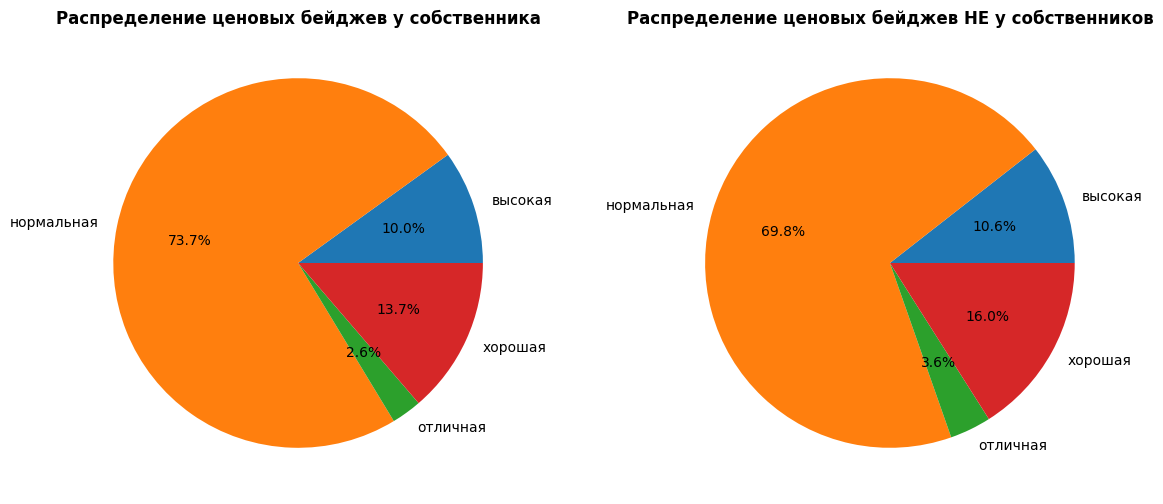

In [448]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
plt.pie(owner_pivot['url'], labels = owner_pivot.index, autopct = '%.1f%%')
plt.title('Распределение ценовых бейджев у собственника', fontweight = 'bold')

plt.subplot(1, 2, 2)
plt.pie(not_owner_pivot['url'], labels = not_owner_pivot.index, autopct = '%.1f%%')
plt.title('Распределение ценовых бейджев НЕ у собственников', fontweight = 'bold')

Не собственники чаще ставят хорошие и отличные цены в отличие от собственников, в то же время собственники чаще получают плашку нормальной цены